In [6]:
# Install needed packages (uncomment these if not installed)
# !pip install xgboost scikit-learn matplotlib seaborn

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

In [7]:
# Load MNIST digits dataset
digits = load_digits()
X = digits.data
y = digits.target


In [15]:
X.shape

(1797, 64)

In [8]:
# Normalize pixel values (0–1)
X = X / 16.0

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [9]:
# Define classifiers
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM": SVC(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
}

In [10]:
# Store results
results = {}

# Train and evaluate models
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True)
    print(f"\n🔍 {name} Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred))
    results[name] = {"model": model, "accuracy": acc, "y_pred": y_pred}


🔍 Logistic Regression Accuracy: 0.9667
              precision    recall  f1-score   support

           0       1.00      0.98      0.99        54
           1       0.88      0.93      0.90        55
           2       1.00      1.00      1.00        53
           3       0.98      0.98      0.98        55
           4       0.98      0.98      0.98        54
           5       0.98      0.96      0.97        55
           6       0.98      0.96      0.97        54
           7       0.98      1.00      0.99        54
           8       0.92      0.88      0.90        52
           9       0.96      0.98      0.97        54

    accuracy                           0.97       540
   macro avg       0.97      0.97      0.97       540
weighted avg       0.97      0.97      0.97       540


🔍 SVM Accuracy: 0.9889
              precision    recall  f1-score   support

           0       1.00      0.98      0.99        54
           1       0.96      1.00      0.98        55
           2  

c:\Users\admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [10:17:25] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



🔍 XGBoost Accuracy: 0.9481
              precision    recall  f1-score   support

           0       0.96      0.93      0.94        54
           1       0.89      0.89      0.89        55
           2       0.98      0.98      0.98        53
           3       0.95      0.98      0.96        55
           4       0.95      1.00      0.97        54
           5       0.95      0.96      0.95        55
           6       1.00      0.96      0.98        54
           7       0.96      1.00      0.98        54
           8       0.90      0.88      0.89        52
           9       0.94      0.89      0.91        54

    accuracy                           0.95       540
   macro avg       0.95      0.95      0.95       540
weighted avg       0.95      0.95      0.95       540




📷 Misclassified by Logistic Regression:


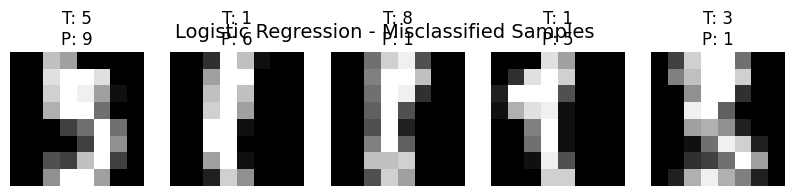


📷 Misclassified by SVM:


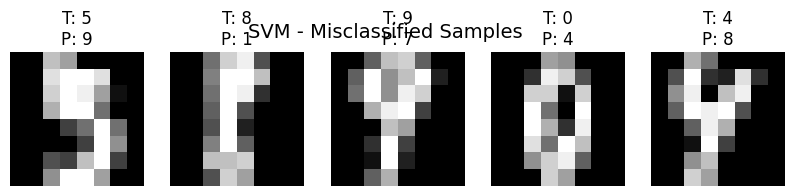


📷 Misclassified by Decision Tree:


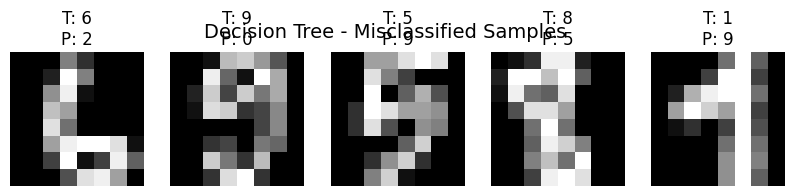


📷 Misclassified by Random Forest:


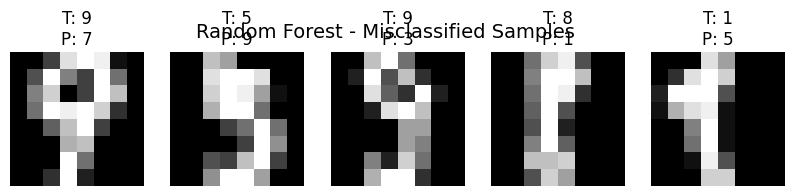


📷 Misclassified by XGBoost:


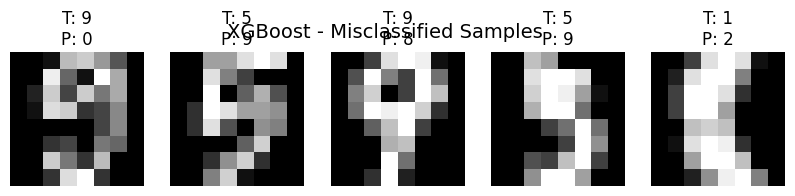

In [11]:
# Visualize 5 misclassified images for each model
for name, info in results.items():
    model = info["model"]
    y_pred = info["y_pred"]
    incorrect = np.where(y_pred != y_test)[0][:5]

    print(f"\n📷 Misclassified by {name}:")
    plt.figure(figsize=(10, 2))
    for i, idx in enumerate(incorrect):
        img = X_test[idx].reshape(8, 8)
        plt.subplot(1, 5, i + 1)
        plt.imshow(img, cmap='gray')
        plt.title(f"T: {y_test[idx]}\nP: {y_pred[idx]}")
        plt.axis('off')
    plt.suptitle(f"{name} - Misclassified Samples", fontsize=14)
    plt.show()


C:\Users\admin\AppData\Local\Temp\ipykernel_15816\3678741515.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=model_names, y=accuracies, palette='viridis')


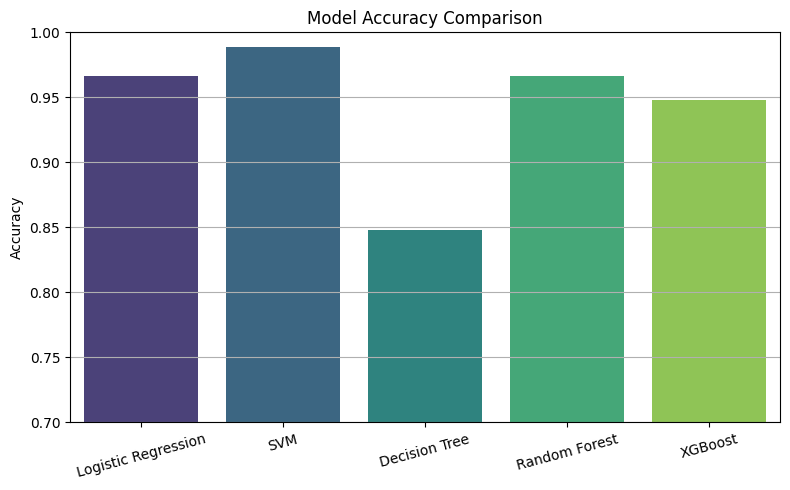

In [13]:
# Bar chart of model accuracies
model_names = list(results.keys())
accuracies = [results[m]['accuracy'] for m in model_names]

plt.figure(figsize=(8, 5))
sns.barplot(x=model_names, y=accuracies, palette='viridis')
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0.7, 1.0)
plt.xticks(rotation=15)
plt.grid(axis='y')
plt.tight_layout()
plt.show()


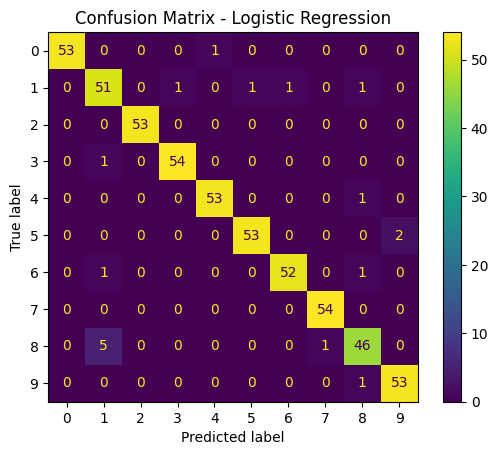

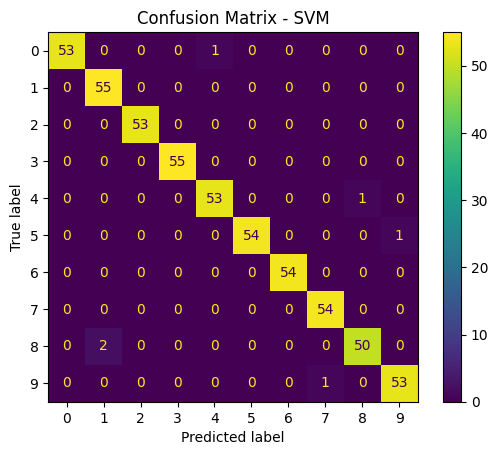

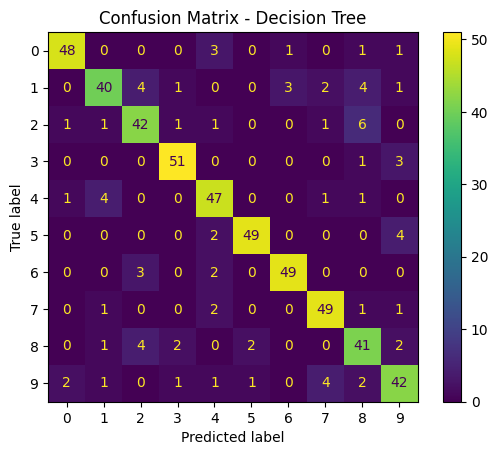

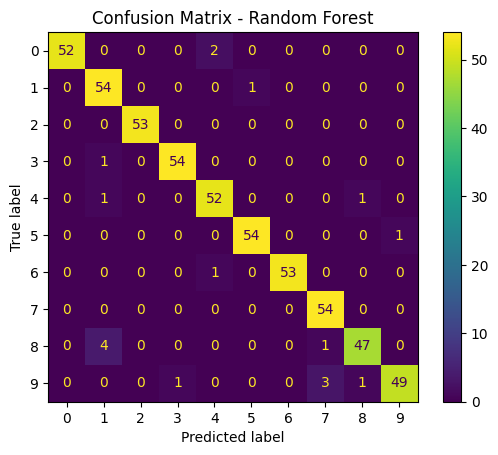

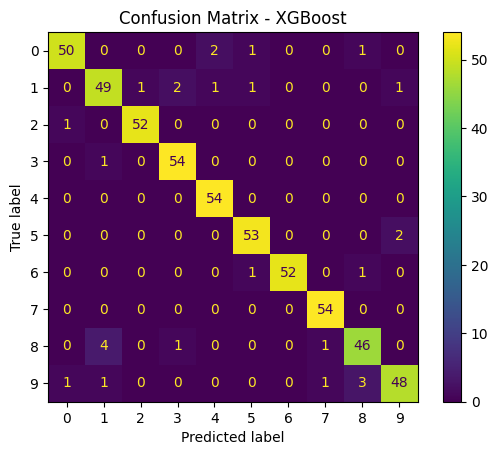

In [14]:
from sklearn.metrics import ConfusionMatrixDisplay

for name, info in results.items():
    ConfusionMatrixDisplay.from_predictions(y_test, info['y_pred'])
    plt.title(f"Confusion Matrix - {name}")
    plt.show()
